# Industrial PPE Detection with YOLOv8

An end-to-end computer vision workflow for detecting workplace PPE classes:

- Hardhat
- Safety Vest
- NO-Hardhat
- NO-Safety Vest
- Person

This notebook is intentionally limited to the parts that belong in an ML experimentation workflow:

**data validation → preprocessing → benchmarking → targeted fine-tuning → evaluation → production model selection → error analysis → deployment verification**

Application code lives outside the notebook in `src/` and `app.py`.

## 1. Project Configuration

All paths are defined once. The notebook avoids machine-specific absolute paths wherever possible.

In [1]:
from pathlib import Path
import gc
import json
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from ultralytics import YOLO

# -------------------------------------------------
# Resolve project root robustly
# -------------------------------------------------
# The notebook is stored inside:
# D:\Yolo\notebooks\
#
# while the dataset, models, src, runs, etc. are in:
# D:\Yolo\
#
# Jupyter uses the notebook folder as the working directory,
# so Path.cwd() alone would incorrectly resolve the project root
# as D:\Yolo\notebooks.

CURRENT_DIR = Path.cwd()

project_candidates = [
    CURRENT_DIR,
    CURRENT_DIR.parent,
    CURRENT_DIR.parent.parent,
]

PROJECT_ROOT = None

for candidate in project_candidates:
    if (candidate / "yolo-ppe-detection").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root containing 'yolo-ppe-detection'. "
        f"Current working directory: {CURRENT_DIR}"
    )

# -------------------------------------------------
# Project paths
# -------------------------------------------------

DATASET_DIR = PROJECT_ROOT / "yolo-ppe-detection"
SOURCE_YAML = DATASET_DIR / "data.yaml"

FILTERED_DATASET = DATASET_DIR / "dataset_filtered"
FILTERED_YAML = FILTERED_DATASET / "data.yaml"

RUNS_DIR = PROJECT_ROOT / "runs"
BENCHMARK_DIR = RUNS_DIR / "benchmark"
TUNING_DIR = RUNS_DIR / "targeted_tuning"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = PROJECT_ROOT / "models"
PRODUCTION_MODEL = MODELS_DIR / "ppe_detector.pt"

SELECTED_CLASSES = [
    "Hardhat",
    "Safety Vest",
    "NO-Hardhat",
    "NO-Safety Vest",
    "Person",
]

DEVICE = 0 if torch.cuda.is_available() else "cpu"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook working directory:", CURRENT_DIR)
print("Resolved project root:", PROJECT_ROOT)
print("Dataset directory:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

Notebook working directory: d:\Yolo\notebooks
Resolved project root: d:\Yolo
Dataset directory: d:\Yolo\yolo-ppe-detection
Dataset exists: True
CUDA available: True
Device: 0


In [36]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## 2. Dataset Validation

Validate the expected YOLO directory structure and read the original dataset configuration before modifying annotations.

In [2]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR}")

if not SOURCE_YAML.exists():
    raise FileNotFoundError(f"data.yaml not found: {SOURCE_YAML}")

with open(SOURCE_YAML, "r", encoding="utf-8") as f:
    source_config = yaml.safe_load(f)

original_names = source_config["names"]

missing_classes = [c for c in SELECTED_CLASSES if c not in original_names]
if missing_classes:
    raise ValueError(f"Selected classes missing from dataset: {missing_classes}")

rows = []
for split in ["train", "valid", "test"]:
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"
    rows.append({
        "split": split,
        "images": len(list(image_dir.glob("*"))) if image_dir.exists() else 0,
        "labels": len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0,
    })

dataset_summary = pd.DataFrame(rows)
dataset_summary

,split,images,labels
0,train,30765,30765
1,valid,8814,8814
2,test,4423,4423


## 3. Class Filtering and Annotation Remapping

The source dataset contains more classes than required. This step keeps only the five project classes and remaps their class IDs to a continuous range beginning at zero.

The operation is deterministic and produces a separate filtered dataset, leaving the original data unchanged.

In [3]:
selected_ids = [original_names.index(c) for c in SELECTED_CLASSES]
class_mapping = {old_id: new_id for new_id, old_id in enumerate(selected_ids)}

if FILTERED_DATASET.exists():
    shutil.rmtree(FILTERED_DATASET)

for split in ["train", "valid", "test"]:
    src_images = DATASET_DIR / split / "images"
    src_labels = DATASET_DIR / split / "labels"
    dst_images = FILTERED_DATASET / split / "images"
    dst_labels = FILTERED_DATASET / split / "labels"

    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    for label_file in src_labels.glob("*.txt"):
        remapped = []

        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                old_id = int(parts[0])
                if old_id in class_mapping:
                    remapped.append(
                        " ".join([str(class_mapping[old_id])] + parts[1:])
                    )

        if not remapped:
            continue

        (dst_labels / label_file.name).write_text(
            "\n".join(remapped),
            encoding="utf-8"
        )

        for ext in [".jpg", ".jpeg", ".png"]:
            src_image = src_images / f"{label_file.stem}{ext}"
            if src_image.exists():
                shutil.copy2(src_image, dst_images / src_image.name)
                break

filtered_config = {
    "path": str(FILTERED_DATASET),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(SELECTED_CLASSES),
    "names": SELECTED_CLASSES,
}

with open(FILTERED_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(filtered_config, f, sort_keys=False)

print("Filtered dataset created:", FILTERED_DATASET)
print("Filtered YAML:", FILTERED_YAML)

Filtered dataset created: d:\Yolo\yolo-ppe-detection\dataset_filtered
Filtered YAML: d:\Yolo\yolo-ppe-detection\dataset_filtered\data.yaml


## 4. Dataset Quality Summary

A single summary is enough to check image-label counts and class imbalance before training.

,split,images,labels
0,train,16968,16968
1,valid,4881,4881
2,test,2459,2459


,Class,Annotations
0,Hardhat,42428
1,Safety Vest,6448
2,NO-Hardhat,12965
3,NO-Safety Vest,2022
4,Person,1449


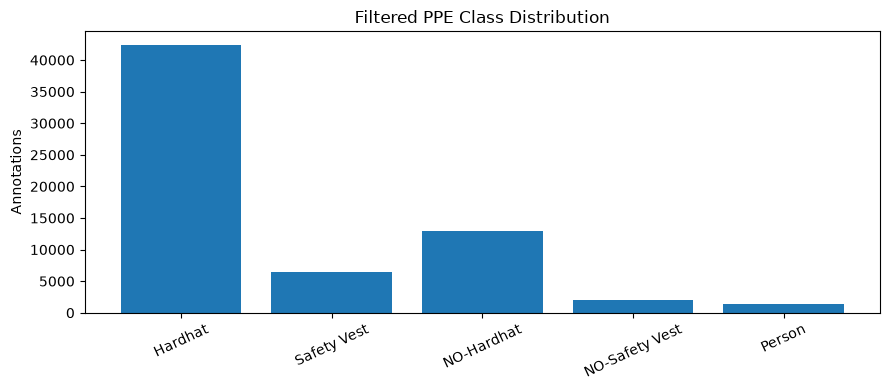

In [4]:
split_rows = []
class_counts = {name: 0 for name in SELECTED_CLASSES}

for split in ["train", "valid", "test"]:
    image_dir = FILTERED_DATASET / split / "images"
    label_dir = FILTERED_DATASET / split / "labels"

    images = list(image_dir.glob("*"))
    labels = list(label_dir.glob("*.txt"))

    split_rows.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
    })

    for label_file in labels:
        for line in label_file.read_text(encoding="utf-8").splitlines():
            parts = line.split()
            if len(parts) == 5:
                class_counts[SELECTED_CLASSES[int(parts[0])]] += 1

filtered_summary = pd.DataFrame(split_rows)
class_distribution = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Annotations"]
)

display(filtered_summary)
display(class_distribution)

plt.figure(figsize=(9, 4))
plt.bar(class_distribution["Class"], class_distribution["Annotations"])
plt.xticks(rotation=25)
plt.ylabel("Annotations")
plt.title("Filtered PPE Class Distribution")
plt.tight_layout()
plt.show()

## 4.1 Roboflow Dataset Provenance

Roboflow was used during dataset preparation and annotation review.

The exported YOLO-format dataset is stored locally so training and deployment
do not depend on the Roboflow API.

In [7]:
roboflow_files = list(DATASET_DIR.glob("*roboflow*"))

for file in roboflow_files:
    print(file.name)

README.roboflow.txt


### Annotation Quality Spot Check

A small random sample is visualized before training to confirm class mappings
and bounding-box quality.

In [8]:
import random

sample_images = random.sample(
    list((FILTERED_DATASET / "train" / "images").glob("*")),
    4
)

sample_images

[WindowsPath('d:/Yolo/yolo-ppe-detection/dataset_filtered/train/images/005676_jpg.rf.bcf2638d1e5b0c06b457a97fcfa4e9e0.jpg'),
 WindowsPath('d:/Yolo/yolo-ppe-detection/dataset_filtered/train/images/RPReplay_Final1667001201_MP4-22_jpg.rf.3e93f2f658b7c031c7a8002b1beac30a.jpg'),
 WindowsPath('d:/Yolo/yolo-ppe-detection/dataset_filtered/train/images/002783_jpg.rf.3bdaaecfcd1a513d5046fe7ff6247f6a.jpg'),
 WindowsPath('d:/Yolo/yolo-ppe-detection/dataset_filtered/train/images/class2_075_jpg.rf.3cab9cc4ae29940f3c88426b03196d37.jpg')]

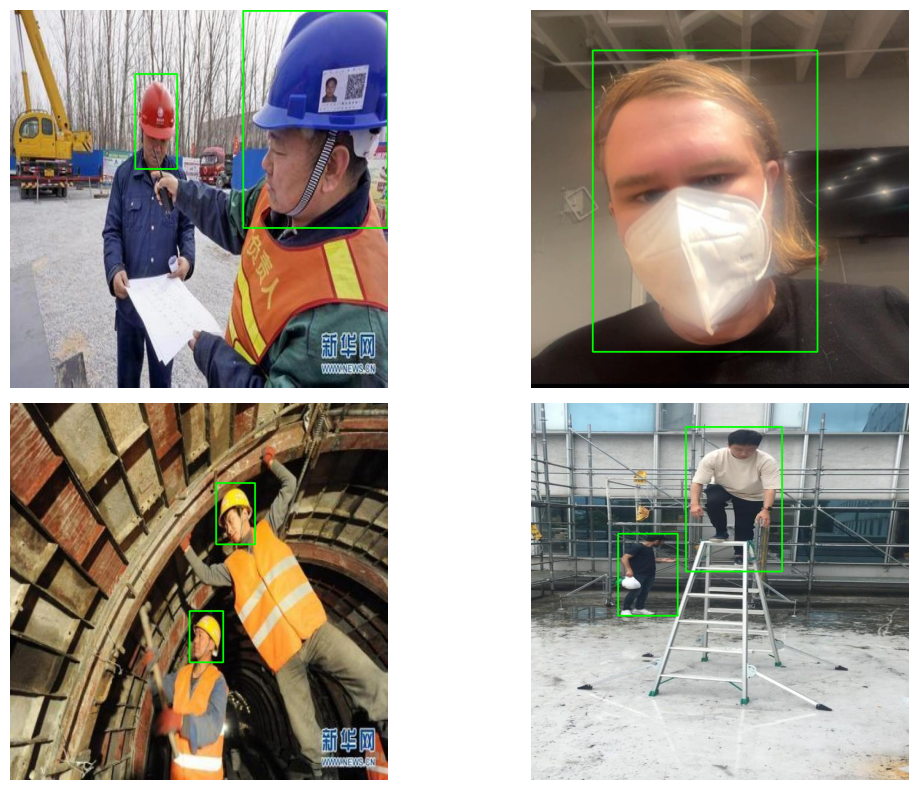

In [9]:
plt.figure(figsize=(12, 8))

for i, image_path in enumerate(sample_images, 1):

    label_path = (
        FILTERED_DATASET
        / "train"
        / "labels"
        / f"{image_path.stem}.txt"
    )

    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]

    for line in label_path.read_text().splitlines():

        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

# 5. Model Benchmarking

Benchmark YOLOv8n, YOLOv8s and YOLOv8m under the same settings.  
`mAP50-95` is the primary model-selection metric; precision, recall and `mAP50` are supporting metrics.

The configuration uses a conservative batch size and worker count to reduce RAM pressure during augmentation.

In [16]:
BENCHMARK_MODELS = {
    "yolov8n": "yolov8n.pt",
    "yolov8s": "yolov8s.pt",
    "yolov8m": "yolov8m.pt",
}

TRAINING_CONFIG = {
    "data": str(FILTERED_YAML),
    "epochs": 1,
    "imgsz": 640,
    "batch": 4,
    "workers": 2,
    "patience": 5,
    "device": DEVICE,
}

TRAINING_CONFIG

{'data': 'd:\\Yolo\\yolo-ppe-detection\\dataset_filtered\\data.yaml',
 'epochs': 1,
 'imgsz': 640,
 'batch': 4,
 'workers': 2,
 'patience': 5,
 'device': 0}

## 5.1 Train Benchmark Models

Training results are saved under `runs/benchmark/`. Memory is explicitly released between models.

In [17]:
trained_model_paths = {}

for model_name, weights in BENCHMARK_MODELS.items():
    print(f"\nTraining {model_name}")

    model = YOLO(weights)
    model.train(
        **TRAINING_CONFIG,
        project=str(BENCHMARK_DIR),
        name=model_name,
        exist_ok=True,
        cache=False,
    )

    best_path = BENCHMARK_DIR / model_name / "weights" / "best.pt"
    if not best_path.exists():
        raise FileNotFoundError(f"Training finished but checkpoint is missing: {best_path}")

    trained_model_paths[model_name] = str(best_path)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

trained_model_paths


Training yolov8n
New https://pypi.org/project/ultralytics/8.4.140 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.139  Python-3.14.3 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\Yolo\yolo-ppe-detection\dataset_filtered\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=

{'yolov8n': 'd:\\Yolo\\runs\\benchmark\\yolov8n\\weights\\best.pt',
 'yolov8s': 'd:\\Yolo\\runs\\benchmark\\yolov8s\\weights\\best.pt',
 'yolov8m': 'd:\\Yolo\\runs\\benchmark\\yolov8m\\weights\\best.pt'}

## 5.2 Validate and Rank Benchmark Models

In [18]:
benchmark_results = []

for model_name, model_path in trained_model_paths.items():
    model = YOLO(model_path)

    metrics = model.val(
        data=str(FILTERED_YAML),
        split="val",
        imgsz=640,
        project=str(RUNS_DIR / "benchmark_validation"),
        name=model_name,
        exist_ok=True,
    )

    benchmark_results.append({
        "Model": model_name,
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "Checkpoint": model_path,
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

benchmark_df = (
    pd.DataFrame(benchmark_results)
    .sort_values("mAP50_95", ascending=False)
    .reset_index(drop=True)
)

benchmark_df.to_csv(ARTIFACTS_DIR / "benchmark_metrics.csv", index=False)
benchmark_df

Ultralytics 8.4.139  Python-3.14.3 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 160.465.4 MB/s, size: 57.6 KB)
val: Scanning D:\Yolo\yolo-ppe-detection\dataset_filtered\valid\labels.cache... 4881 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4881/4881 974.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 306/306 4.2it/s 1:130.3sss
                   all       4881      13099      0.571      0.439      0.412      0.207
               Hardhat       3191       8952      0.656      0.556      0.596      0.281
           Safety Vest        609       1287      0.258      0.181      0.178     0.0818
            NO-Hardhat        865       2222      0.493      0.728      0.597      0.328
        NO-Safety Vest        189        361          1          0     0.0295

,Model,Precision,Recall,mAP50,mAP50_95,Checkpoint
0,yolov8n,0.570999,0.438929,0.411676,0.207384,d:\Yolo\runs\benchmark\yolov8n\weights\best.pt
1,yolov8s,0.542898,0.334772,0.294792,0.134326,d:\Yolo\runs\benchmark\yolov8s\weights\best.pt
2,yolov8m,0.783475,0.234210,0.227013,0.105174,d:\Yolo\runs\benchmark\yolov8m\weights\best.pt


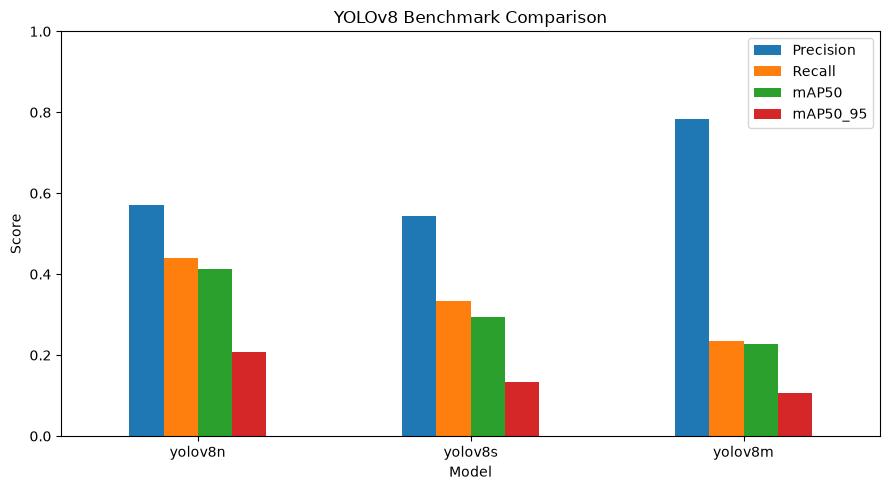

In [19]:
plot_df = benchmark_df.set_index("Model")[["Precision", "Recall", "mAP50", "mAP50_95"]]
plot_df.plot(kind="bar", figsize=(9, 5))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("YOLOv8 Benchmark Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Targeted Fine-Tuning

This is a small targeted fine-tuning stage, not an exhaustive hyperparameter search.

The strongest benchmark checkpoint is fine-tuned with two AdamW learning-rate settings already used in the original project.

In [20]:
best_benchmark = benchmark_df.iloc[0]
best_benchmark_name = best_benchmark["Model"]
best_benchmark_path = best_benchmark["Checkpoint"]

TUNING_EXPERIMENTS = [
    {
        "name": "adamw_lr001_b4",
        "optimizer": "AdamW",
        "lr0": 0.001,
        "weight_decay": 0.0005,
        "batch": 4,
    },
    {
        "name": "adamw_lr0005_b4",
        "optimizer": "AdamW",
        "lr0": 0.0005,
        "weight_decay": 0.0005,
        "batch": 4,
    },
]

tuned_model_paths = {}

for exp in TUNING_EXPERIMENTS:
    print(f"\nFine-tuning {exp['name']}")

    model = YOLO(best_benchmark_path)
    model.train(
        data=str(FILTERED_YAML),
        epochs=2,
        imgsz=640,
        batch=exp["batch"],
        workers=2,
        optimizer=exp["optimizer"],
        lr0=exp["lr0"],
        weight_decay=exp["weight_decay"],
        device=DEVICE,
        project=str(TUNING_DIR),
        name=exp["name"],
        exist_ok=True,
        cache=False,
    )

    best_path = TUNING_DIR / exp["name"] / "weights" / "best.pt"
    tuned_model_paths[exp["name"]] = str(best_path)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

tuned_model_paths


Fine-tuning adamw_lr001_b4
New https://pypi.org/project/ultralytics/8.4.140 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.139  Python-3.14.3 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\Yolo\yolo-ppe-detection\dataset_filtered\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=

{'adamw_lr001_b4': 'd:\\Yolo\\runs\\targeted_tuning\\adamw_lr001_b4\\weights\\best.pt',
 'adamw_lr0005_b4': 'd:\\Yolo\\runs\\targeted_tuning\\adamw_lr0005_b4\\weights\\best.pt'}

## 6.1 Validate Fine-Tuned Candidates

In [21]:
tuning_results = []

for exp_name, model_path in tuned_model_paths.items():
    model = YOLO(model_path)

    metrics = model.val(
        data=str(FILTERED_YAML),
        split="val",
        imgsz=640,
        project=str(RUNS_DIR / "tuning_validation"),
        name=exp_name,
        exist_ok=True,
    )

    tuning_results.append({
        "Model": exp_name,
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
        "Checkpoint": model_path,
        "Type": "Targeted fine-tune",
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

tuning_df = (
    pd.DataFrame(tuning_results)
    .sort_values("mAP50_95", ascending=False)
    .reset_index(drop=True)
)

tuning_df.to_csv(ARTIFACTS_DIR / "tuning_metrics.csv", index=False)
tuning_df

Ultralytics 8.4.139  Python-3.14.3 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 140.623.4 MB/s, size: 57.6 KB)
val: Scanning D:\Yolo\yolo-ppe-detection\dataset_filtered\valid\labels.cache... 4881 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4881/4881 584.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 306/306 3.8it/s 1:200.2sss
                   all       4881      13099      0.671      0.544      0.561      0.332
               Hardhat       3191       8952      0.749      0.689      0.716      0.367
           Safety Vest        609       1287      0.538       0.38      0.437      0.256
            NO-Hardhat        865       2222       0.66      0.798      0.767      0.448
        NO-Safety Vest        189        361          1          0     0.0793

,Model,Precision,Recall,mAP50,mAP50_95,Checkpoint,Type
0,adamw_lr0005_b4,0.718124,0.551083,0.582423,0.347167,d:\Yolo\runs\targeted_tuning\adamw_lr0005_b4\w...,Targeted fine-tune
1,adamw_lr001_b4,0.670809,0.543982,0.561078,0.331771,d:\Yolo\runs\targeted_tuning\adamw_lr001_b4\we...,Targeted fine-tune


# 7. Production Model Selection

The production checkpoint is selected from the strongest benchmark model and strongest fine-tuned candidate using `mAP50-95`.

In [22]:
benchmark_candidate = benchmark_df.iloc[0].to_dict()
benchmark_candidate["Type"] = "Benchmark"

candidates = [benchmark_candidate]

if not tuning_df.empty:
    candidates.append(tuning_df.iloc[0].to_dict())

production_candidates = (
    pd.DataFrame(candidates)
    .sort_values("mAP50_95", ascending=False)
    .reset_index(drop=True)
)

production_candidates

,Model,Precision,Recall,mAP50,mAP50_95,Checkpoint,Type
0,adamw_lr0005_b4,0.718124,0.551083,0.582423,0.347167,d:\Yolo\runs\targeted_tuning\adamw_lr0005_b4\w...,Targeted fine-tune
1,yolov8n,0.570999,0.438929,0.411676,0.207384,d:\Yolo\runs\benchmark\yolov8n\weights\best.pt,Benchmark


## 7.1 Export Production Artifact

Deployment code never reads experiment-specific `runs/` paths.  
The selected checkpoint is copied to the stable production path:

`models/ppe_detector.pt`

In [23]:
winner = production_candidates.iloc[0]
winner_checkpoint = Path(winner["Checkpoint"])

if not winner_checkpoint.exists():
    raise FileNotFoundError(f"Selected checkpoint not found: {winner_checkpoint}")

shutil.copy2(winner_checkpoint, PRODUCTION_MODEL)

metadata = {
    "model": str(winner["Model"]),
    "type": str(winner["Type"]),
    "precision": float(winner["Precision"]),
    "recall": float(winner["Recall"]),
    "map50": float(winner["mAP50"]),
    "map50_95": float(winner["mAP50_95"]),
    "production_checkpoint": str(PRODUCTION_MODEL),
}

with open(ARTIFACTS_DIR / "production_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))
print("Production model exists:", PRODUCTION_MODEL.exists())

{
  "model": "adamw_lr0005_b4",
  "type": "Targeted fine-tune",
  "precision": 0.7181236654498351,
  "recall": 0.5510833130810286,
  "map50": 0.5824229135780745,
  "map50_95": 0.3471671857688323,
  "production_checkpoint": "d:\\Yolo\\models\\ppe_detector.pt"
}
Production model exists: True


# 8. Error Analysis

Error analysis is intentionally compact: sample test images, run inference once, and group cases into:

- good detections
- low-confidence detections
- no detections

This is enough to inspect model failure modes without duplicating many visualization cells.

In [24]:
production_model = YOLO(str(PRODUCTION_MODEL))

test_image_dir = FILTERED_DATASET / "test" / "images"
test_images = sorted([p for p in test_image_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])

sample_images = test_images[:50]
rows = []

for image_path in sample_images:
    result = production_model.predict(
        source=str(image_path),
        conf=0.25,
        iou=0.60,
        verbose=False,
    )[0]

    if result.boxes is None or len(result.boxes) == 0:
        rows.append({
            "Image": image_path.name,
            "Image_Path": str(image_path),
            "Num_Detections": 0,
            "Min_Confidence": None,
            "Classes": [],
            "Category": "No detection",
        })
        continue

    class_ids = result.boxes.cls.cpu().numpy().astype(int).tolist()
    confidences = result.boxes.conf.cpu().numpy().tolist()
    class_names = [result.names[i] for i in class_ids]
    min_conf = min(confidences)

    category = "Good detection" if min_conf >= 0.60 else "Low confidence"

    rows.append({
        "Image": image_path.name,
        "Image_Path": str(image_path),
        "Num_Detections": len(class_ids),
        "Min_Confidence": min_conf,
        "Classes": class_names,
        "Category": category,
    })

error_df = pd.DataFrame(rows)
display(error_df["Category"].value_counts().rename_axis("Category").to_frame("Count"))
error_df.head()

,Count
Category,
Low confidence,48
Good detection,2


,Image,Image_Path,Num_Detections,Min_Confidence,Classes,Category
0,-1003-_png_jpg.rf.40a811e60f1b213fd091d11af90a...,d:\Yolo\yolo-ppe-detection\dataset_filtered\te...,4,0.260008,"[Hardhat, Hardhat, Hardhat, Hardhat]",Low confidence
1,-1006-_png_jpg.rf.5491519cec0079e60e2aed91c7f1...,d:\Yolo\yolo-ppe-detection\dataset_filtered\te...,3,0.428713,"[Hardhat, Hardhat, Hardhat]",Low confidence
2,-1012-_png_jpg.rf.7f210e57ef5776449bd8659c2314...,d:\Yolo\yolo-ppe-detection\dataset_filtered\te...,2,0.486186,"[Hardhat, Hardhat]",Low confidence
3,-1016-_png_jpg.rf.697c859fe7c052c29a2703bc99d8...,d:\Yolo\yolo-ppe-detection\dataset_filtered\te...,1,0.442219,[Hardhat],Low confidence
4,-1037-_png_jpg.rf.b05711a1743220147897c8ab02e8...,d:\Yolo\yolo-ppe-detection\dataset_filtered\te...,3,0.319637,"[Hardhat, Hardhat, Hardhat]",Low confidence


## 8.1 Visual Review

Display a small number of representative cases instead of maintaining separate visualization blocks for every category.

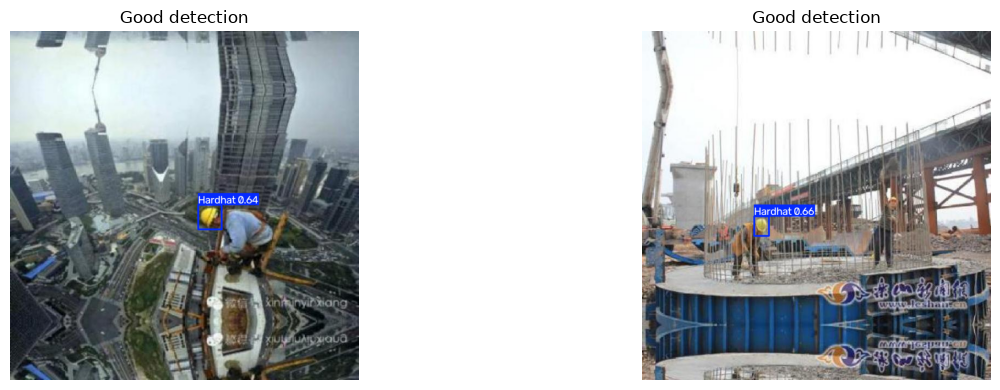

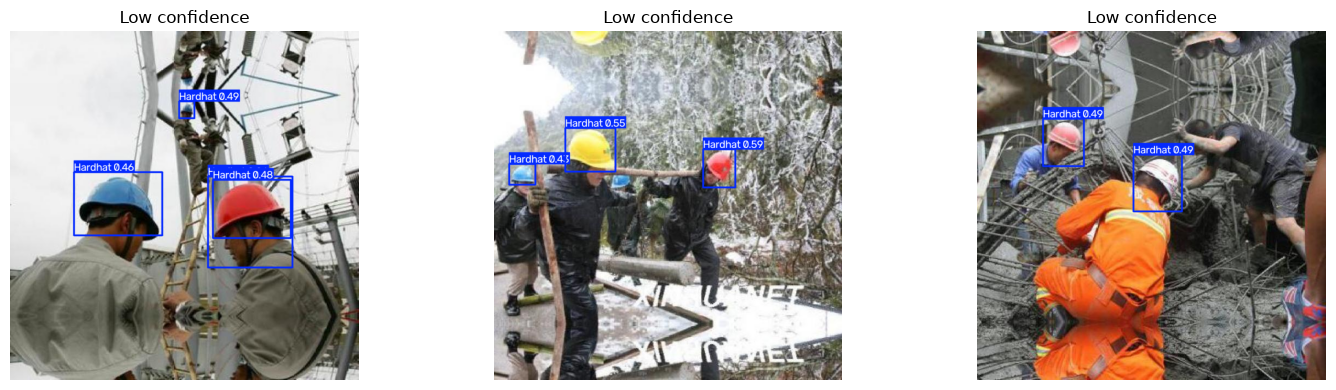

No examples for: No detection


In [25]:
def show_examples(df, category, n=3, conf=0.25):
    subset = df[df["Category"] == category].head(n)

    if subset.empty:
        print(f"No examples for: {category}")
        return

    plt.figure(figsize=(15, 4))

    for i, (_, row) in enumerate(subset.iterrows(), start=1):
        result = production_model.predict(
            source=row["Image_Path"],
            conf=conf,
            iou=0.60,
            verbose=False,
        )[0]

        annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(subset), i)
        plt.imshow(annotated)
        plt.title(category)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

for category in ["Good detection", "Low confidence", "No detection"]:
    show_examples(error_df, category)

## 8.2 Confidence Threshold Sensitivity

Compare a few thresholds on one representative image. This supports choosing a practical inference threshold without turning the notebook into a large visualization report.

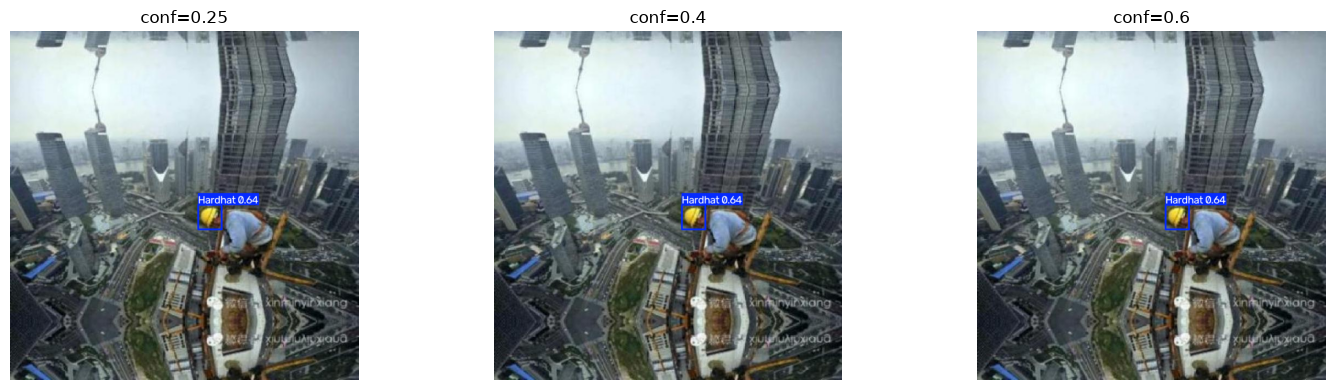

In [26]:
if not error_df.empty:
    preferred = error_df[error_df["Category"] == "Good detection"]
    sample_path = Path(
        preferred.iloc[0]["Image_Path"] if not preferred.empty
        else error_df.iloc[0]["Image_Path"]
    )

    thresholds = [0.25, 0.40, 0.60]
    plt.figure(figsize=(15, 4))

    for i, threshold in enumerate(thresholds, start=1):
        result = production_model.predict(
            source=str(sample_path),
            conf=threshold,
            iou=0.60,
            verbose=False,
        )[0]

        annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(thresholds), i)
        plt.imshow(annotated)
        plt.title(f"conf={threshold}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# 9. Model Explainability

Grad-CAM is used as a qualitative diagnostic to inspect which image regions
influence the final YOLOv8 predictions.

Explainability results are interpreted together with detection metrics and
error analysis.

In [28]:
for i, layer in enumerate(production_model.model.model):
    print(i, layer.__class__.__name__)

0 Conv
1 Conv
2 C2f
3 Conv
4 C2f
5 Conv
6 C2f
7 Conv
8 C2f
9 SPPF
10 Upsample
11 Concat
12 C2f
13 Upsample
14 Concat
15 C2f
16 Conv
17 Concat
18 C2f
19 Conv
20 Concat
21 C2f
22 Detect


In [29]:
import torch
import torch.nn.functional as F


class YOLOGradCAM:

    def __init__(self, model, layer_ids=(15, 18, 21)):
        self.model = model.model
        self.activations = {}
        self.gradients = {}
        self.hooks = []

        for idx in layer_ids:
            layer = self.model.model[idx]

            self.hooks.append(
                layer.register_forward_hook(
                    self._save_activation(idx)
                )
            )

            self.hooks.append(
                layer.register_full_backward_hook(
                    self._save_gradient(idx)
                )
            )

    def _save_activation(self, idx):

        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                self.activations[idx] = output

        return hook

    def _save_gradient(self, idx):

        def hook(module, grad_input, grad_output):
            if grad_output:
                self.gradients[idx] = grad_output[0]

        return hook

    def generate(self, image_tensor):

        self.model.zero_grad()

        output = self.model(image_tensor)

        predictions = (
            output[0]
            if isinstance(output, tuple)
            else output
        )

        score = predictions[:, 4:, :].max()

        score.backward()

        cams = []

        for idx in self.activations:

            activation = self.activations[idx]
            gradient = self.gradients[idx]

            weights = gradient.mean(
                dim=(2, 3),
                keepdim=True
            )

            cam = (
                weights * activation
            ).sum(dim=1, keepdim=True)

            cam = F.relu(cam)

            cam = F.interpolate(
                cam,
                size=image_tensor.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            cam -= cam.min()
            cam /= cam.max() + 1e-8

            cams.append(cam)

        return torch.stack(cams).mean(0)[0, 0]

    def close(self):

        for hook in self.hooks:
            hook.remove()

## 9.1 Grad-CAM Visualization

A representative successful detection is selected from the earlier error-analysis
results.

In [106]:
good_cases = error_df[
    error_df["Category"] == "Good detection"
]

image_path = Path(
    good_cases.iloc[0]["Image_Path"]
)

In [107]:
from PIL import Image
from torchvision.transforms import v2

image = Image.open(image_path).convert("RGB")

transform = v2.Compose([
    v2.Resize((640, 640)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

image_tensor = (
    transform(image)
    .unsqueeze(0)
    .to(DEVICE)
)

In [108]:
import importlib
import src.gradcam

importlib.reload(src.gradcam)

from src.gradcam import YOLOGradCAM

In [109]:
gradcam_model = YOLO(
    str(PRODUCTION_MODEL)
)

gradcam_model.to(DEVICE)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0

In [110]:
from src.gradcam import YOLOGradCAM

gradcam = YOLOGradCAM(
    gradcam_model,
    layer_id=21
)

heatmap = gradcam.generate(
    image_tensor
)

gradcam.close()

In [113]:
image_tensor = (
    image_tensor
    .to(gradcam_model.device)
)

In [114]:
heatmap = cv2.resize(
    heatmap,
    (640, 640)
)

heatmap_color = cv2.applyColorMap(
    (heatmap * 255).astype("uint8"),
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

In [115]:
import numpy as np
original = np.array(
    image.resize((640, 640))
)

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

In [117]:
from ultralytics import YOLO

production_model = YOLO(str(PRODUCTION_MODEL))

In [118]:
hooks = sum(
    len(module._forward_hooks)
    for module in production_model.model.modules()
)

print("Forward hooks:", hooks)

Forward hooks: 0


In [119]:
result = production_model.predict(
    str(image_path),
    conf=0.25,
    verbose=False
)[0]

detected = cv2.cvtColor(
    result.plot(),
    cv2.COLOR_BGR2RGB
)


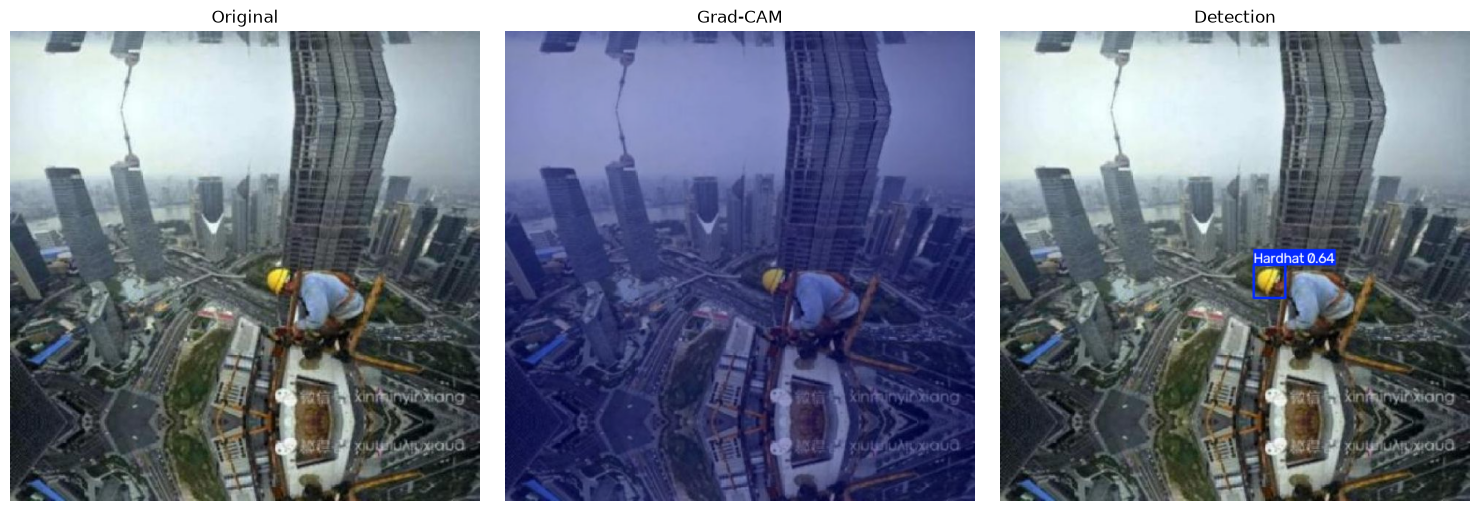

In [120]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(detected)
plt.title("Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

## 9.2 Explainability Interpretation

Grad-CAM is treated as a qualitative diagnostic rather than a performance metric.

Useful attention should overlap with PPE equipment or relevant human regions.
Strong activation on irrelevant background areas can indicate dataset bias or
shortcut learning.

The explanation is therefore considered together with precision, recall,
mAP and error-analysis results.

# 10. Deployment Verification

Training and deployment are separated.

The notebook produces `models/ppe_detector.pt`.  
The application layer should use:

- `src/model.py` — production model loading
- `src/inference.py` — reusable inference functions
- `app.py` — Streamlit interface
- `requirements.txt` — deployment dependencies

The following checks confirm that the deployment package exists without embedding application code inside the training notebook.

In [121]:
required_files = {
    "production_model": PROJECT_ROOT / "models" / "ppe_detector.pt",
    "model_loader": PROJECT_ROOT / "src" / "model.py",
    "inference_module": PROJECT_ROOT / "src" / "inference.py",
    "streamlit_app": PROJECT_ROOT / "app.py",
    "requirements": PROJECT_ROOT / "requirements.txt",
}

deployment_status = pd.DataFrame([
    {
        "Component": name,
        "Path": str(path.relative_to(PROJECT_ROOT)),
        "Exists": path.exists(),
    }
    for name, path in required_files.items()
])

deployment_status

,Component,Path,Exists
0,production_model,models\ppe_detector.pt,True
1,model_loader,src\model.py,True
2,inference_module,src\inference.py,True
3,streamlit_app,app.py,True
4,requirements,requirements.txt,True


## 10.1 Production Inference Smoke Test

This verifies the same `src/` code path that the deployed application will use.  
No training or experiment code is required at application startup.

In [122]:
from src.model import load_model
from src.inference import predict_image
from PIL import Image

if not test_images:
    raise RuntimeError("No test images available for deployment smoke test.")

app_model = load_model()
image = Image.open(test_images[0]).convert("RGB")

annotated, detections, inference_time = predict_image(
    app_model,
    image,
    confidence=0.25,
)

print("Production inference successful")
print("Detections:", len(detections))
print(f"Inference time: {inference_time:.3f} s")

Production inference successful
Detections: 6
Inference time: 0.134 s


# 11. Deployment Architecture

The final system is deliberately simple:

```text
Dataset + Training Notebook
          ↓
 models/ppe_detector.pt
          ↓
     src/model.py
          ↓
   src/inference.py
          ↓
        app.py
          ↓
   Streamlit deployment
```

The notebook is used for experimentation and model selection only.  
The hosted application loads the exported checkpoint and performs inference directly.

This avoids retraining, benchmark reruns, hard-coded local paths, and notebook dependencies during deployment.

# 12. Final Project Outputs

After a successful run, the project should contain:

```text
models/
└── ppe_detector.pt

artifacts/
├── benchmark_metrics.csv
├── tuning_metrics.csv
└── production_model_metadata.json

src/
├── __init__.py
├── model.py
└── inference.py

app.py
requirements.txt
```

The notebook now serves as a concise experiment record rather than the application itself.